# TP YOLOv8 : Entraînement sur vos propres données (custom)

Bienvenue dans ce TP ! Vous allez apprendre à entraîner un modèle YOLOv8 sur un jeu de données personnalisé. Ce notebook vous guide étape par étape, en français, pour réaliser un entraînement complet sur vos propres images annotées.

## 1️⃣ Installation des dépendances

Installez les librairies nécessaires pour utiliser YOLOv8 et manipuler les images. Exécutez la cellule suivante.

In [32]:
# Installer ultralytics, opencv-python, matplotlib, pillow
!pip install ultralytics opencv-python matplotlib pillow -q

# Vérifier les versions 
import ultralytics
import cv2
import matplotlib
import PIL

print(f"ultralytics version : {ultralytics.__version__}")
print(f"opencv version : {cv2.__version__}")
print(f"matplotlib version : {matplotlib.__version__}")
print(f"pillow version : {PIL.__version__}")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ultralytics version : 8.4.36
opencv version : 4.13.0
matplotlib version : 3.10.8
pillow version : 12.2.0


## 2️⃣ Import des librairies

Importez toutes les librairies nécessaires pour la suite du TP.

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from pathlib import Path
import os
import yaml
from ultralytics import YOLO

print("✅ Librairies importées avec succès !")

✅ Librairies importées avec succès !


## 3️⃣ Organisation et préparation des données custom

Votre dataset se trouve dans `yolo_dataset/` avec la structure suivante :
- `yolo_dataset/images/` : toutes les images
- `yolo_dataset/labels/` : les fichiers d'annotations YOLO
- `yolo_dataset/classes.txt` : la liste des classes

**Format YOLO :** Chaque ligne d'un fichier `.txt` :
```
<class_id> <x_center> <y_center> <width> <height>
```
(valeurs normalisées entre 0 et 1)

➡️ On va automatiquement découper ces données en **train** et **validation**.

In [34]:
import shutil
import random

# === CONFIGURATION ===
# Déterminer automatiquement le dossier racine du notebook
BASE_DIR = Path(os.path.abspath('')).resolve()
print(f"📂 Dossier de travail : {BASE_DIR}")

DATASET_DIR = BASE_DIR / 'yolo_dataset'
OUTPUT_DIR = BASE_DIR / 'yolo_split'  # Dossier de sortie avec le split train/val
VAL_RATIO = 0.2  # 20% des images pour la validation

# Lire les classes depuis classes.txt
with open(DATASET_DIR / 'classes.txt', 'r') as f:
    classes = [line.strip() for line in f if line.strip()]
print(f"📋 Classes trouvées : {classes}")

# Lister toutes les images
image_extensions = {'.jpg', '.jpeg', '.png', '.webp', '.avif', '.bmp'}
all_images = [f for f in (DATASET_DIR / 'images').iterdir() if f.suffix.lower() in image_extensions]
print(f"📸 Nombre total d'images : {len(all_images)}")

# Vérifier que chaque image a un label correspondant
paired = []
missing_labels = []
for img_path in all_images:
    label_path = DATASET_DIR / 'labels' / (img_path.stem + '.txt')
    if label_path.exists():
        paired.append((img_path, label_path))
    else:
        missing_labels.append(img_path.name)

if missing_labels:
    print(f"⚠️  Images sans label : {missing_labels}")
print(f"✅ Paires image/label valides : {len(paired)}")

# Mélanger et découper
random.seed(42)
random.shuffle(paired)
split_idx = int(len(paired) * (1 - VAL_RATIO))
train_pairs = paired[:split_idx]
val_pairs = paired[split_idx:]

print(f"\n📊 Découpage automatique :")
print(f"   Train : {len(train_pairs)} images")
print(f"   Val   : {len(val_pairs)} images")

# Créer l'arborescence train/val
for split, pairs in [('train', train_pairs), ('val', val_pairs)]:
    img_dir = OUTPUT_DIR / 'images' / split
    lbl_dir = OUTPUT_DIR / 'labels' / split
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
    for img_path, label_path in pairs:
        shutil.copy2(img_path, img_dir / img_path.name)
        shutil.copy2(label_path, lbl_dir / label_path.name)

print(f"\n✅ Dataset découpé dans '{OUTPUT_DIR}' !")

📂 Dossier de travail : /Users/logame/Documents/cours ECM/yolo_training
📋 Classes trouvées : ['chien', 'chat']
📸 Nombre total d'images : 10
✅ Paires image/label valides : 10

📊 Découpage automatique :
   Train : 8 images
   Val   : 2 images

✅ Dataset découpé dans '/Users/logame/Documents/cours ECM/yolo_training/yolo_split' !


## 4️⃣ Vérification de l’annotation (format YOLO)

Affichons quelques images avec leurs annotations pour vérifier la qualité des labels.

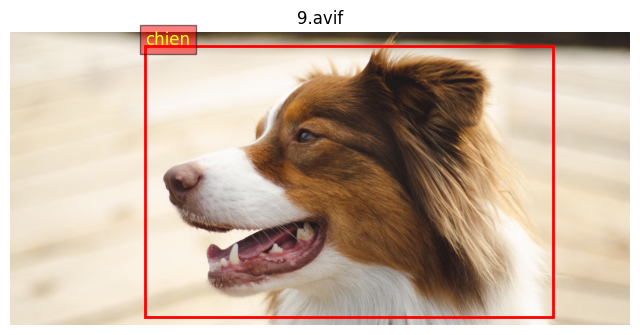

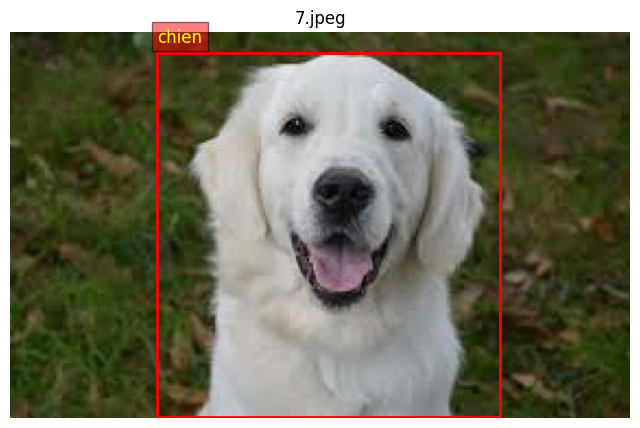

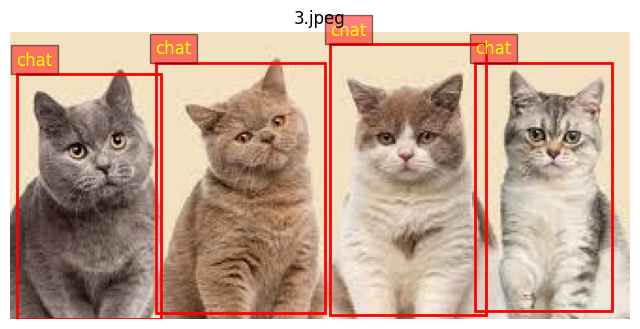

In [35]:
# Afficher quelques images avec leurs bounding boxes
def plot_yolo_label(image_path, label_path, class_names=None):
    img = np.array(Image.open(image_path))
    h, w = img.shape[:2]
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, xc, yc, bw, bh = map(float, parts)
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                x2 = (xc + bw/2) * w
                y2 = (yc + bh/2) * h
                rect = Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
                ax.add_patch(rect)
                if class_names:
                    ax.text(x1, y1-5, class_names[int(cls)], color='yellow', fontsize=12,
                            bbox=dict(facecolor='red', alpha=0.5))
    ax.set_title(Path(image_path).name)
    ax.axis('off')
    plt.show()

# Afficher des images du split train
train_images = list((OUTPUT_DIR / 'images' / 'train').glob('*'))
if train_images:
    for img_path in random.sample(train_images, min(3, len(train_images))):
        label_path = OUTPUT_DIR / 'labels' / 'train' / (img_path.stem + '.txt')
        plot_yolo_label(img_path, label_path, class_names=classes)
else:
    print("⚠️  Aucune image trouvée dans le split train.")

## 5️⃣ Configuration du fichier de données YAML

Le fichier `data.yaml` est créé automatiquement avec les chemins absolus vers les dossiers `train` et `val`, et les classes lues depuis `classes.txt`.

In [36]:
# Créer automatiquement le fichier data.yaml avec les bons chemins
nc = len(classes)
data_yaml = {
    'train': str((OUTPUT_DIR / 'images' / 'train').resolve()),
    'val': str((OUTPUT_DIR / 'images' / 'val').resolve()),
    'nc': nc,
    'names': classes
}

yaml_path = str(BASE_DIR / 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("✅ Fichier data.yaml créé :")
for k, v in data_yaml.items():
    print(f"  {k}: {v}")

✅ Fichier data.yaml créé :
  train: /Users/logame/Documents/cours ECM/yolo_training/yolo_split/images/train
  val: /Users/logame/Documents/cours ECM/yolo_training/yolo_split/images/val
  nc: 2
  names: ['chien', 'chat']


## 6️⃣ Chargement et configuration du modèle YOLOv8

Chargeons un modèle YOLOv8 pré-entraîné (par exemple, yolov8n.pt) prêt à être fine-tuné sur vos données custom.

In [37]:
# Charger le modèle YOLOv8 nano (le plus rapide pour débuter)
model = YOLO('yolov8n.pt')
print("✅ Modèle YOLOv8 chargé et prêt à être entraîné !")

✅ Modèle YOLOv8 chargé et prêt à être entraîné !


## 7️⃣ Lancement de l’entraînement

Lançons l'entraînement du modèle sur vos données custom. Vous pouvez ajuster les paramètres selon vos besoins (nombre d'époques, taille d'image, batch size, etc.).

In [38]:
# Lancer l'entraînement
results = model.train(
    data=yaml_path,           # Chemin absolu vers le fichier YAML
    epochs=100,               # Nombre d'époques (à ajuster)
    imgsz=640,                # Taille des images
    batch=2,                  # Batch size (à ajuster selon la RAM)
    project=str(BASE_DIR / 'runs' / 'train'),  # Dossier de sortie
    name='yolov8_custom'      # Nom de l'expérience
)
print("✅ Entraînement terminé !")

Ultralytics 8.4.36 🚀 Python-3.14.3 torch-2.11.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/logame/Documents/cours ECM/yolo_training/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

## 8️⃣ Visualisation des courbes d’apprentissage

Affichons les courbes de loss, précision, rappel et mAP générées pendant l'entraînement.

📂 Résultats trouvés dans : /Users/logame/Documents/cours ECM/yolo_training/runs/train/yolov8_custom


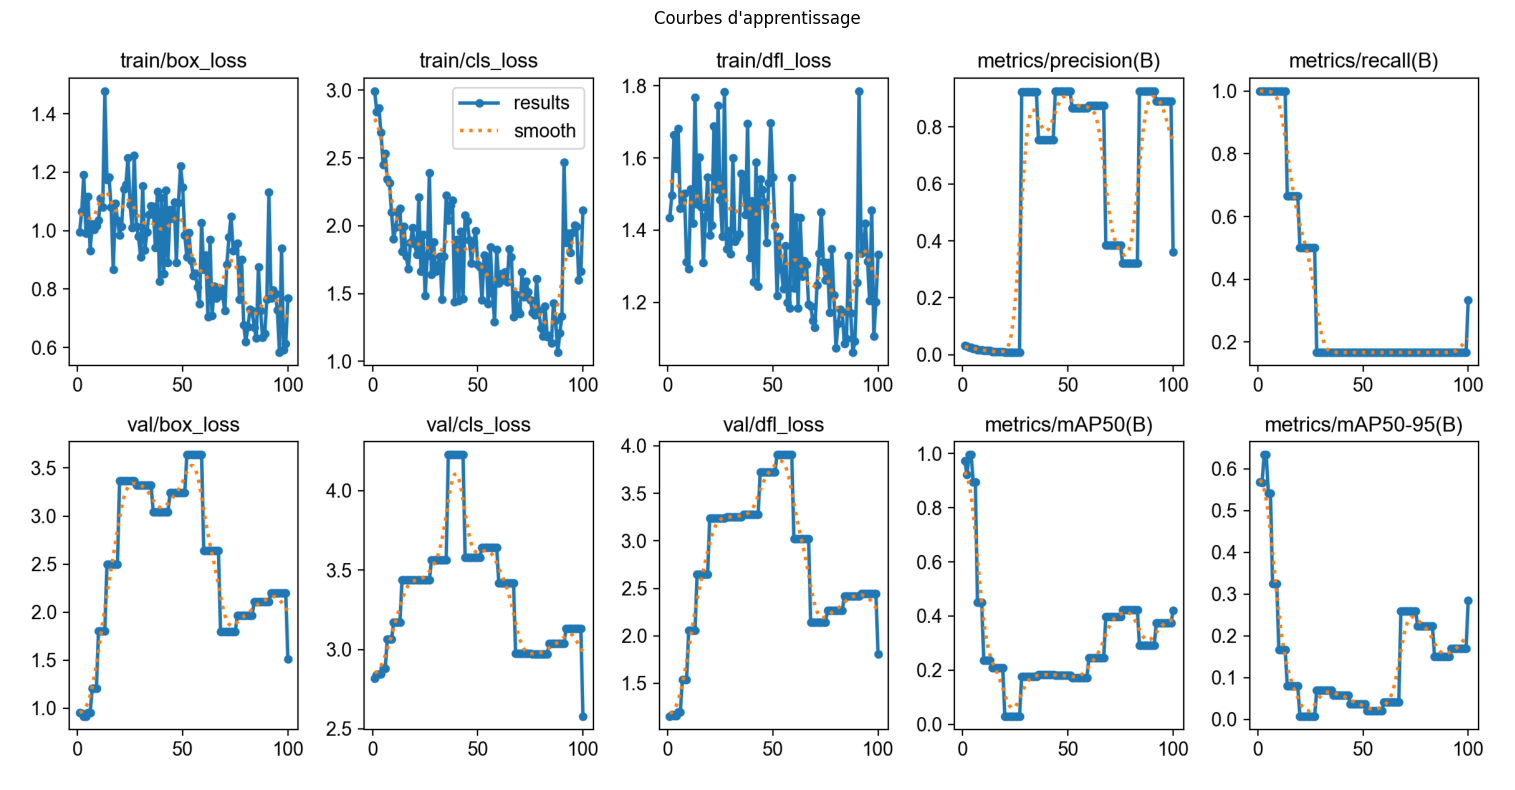

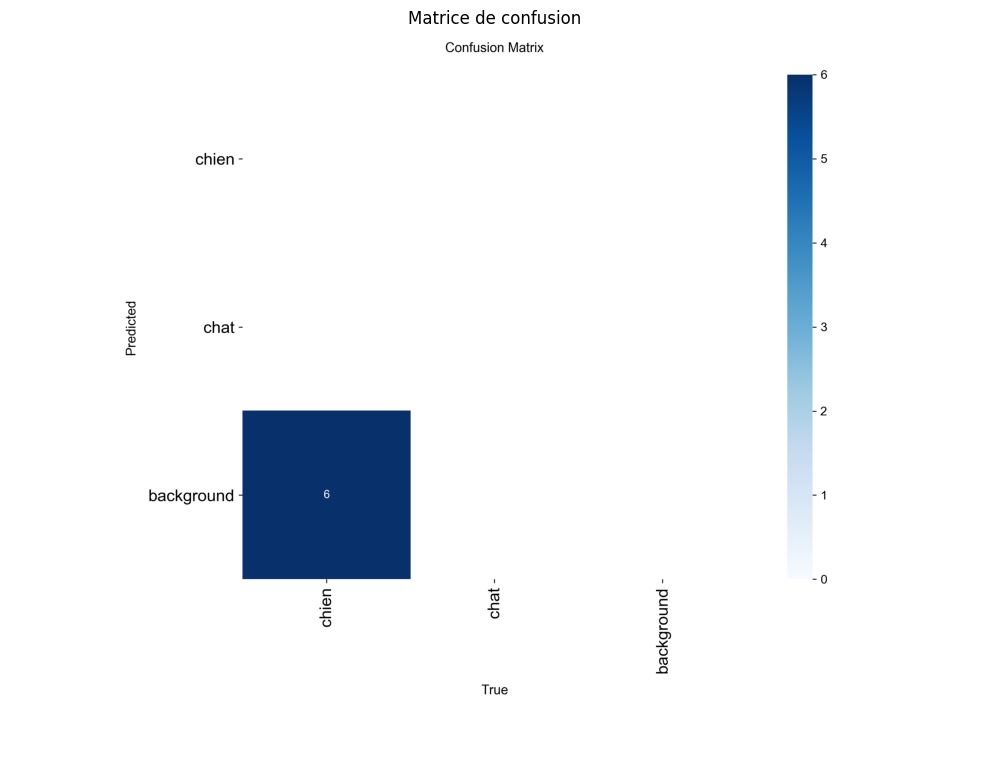

In [39]:
# Afficher les courbes d'apprentissage
# On cherche le bon dossier automatiquement
candidates = [
    BASE_DIR / 'runs' / 'train' / 'yolov8_custom',
    Path.home() / 'runs' / 'detect' / 'runs' / 'train' / 'yolov8_custom',
]
# Ajouter le dernier dossier trainN créé dans ~/runs/detect/ et dans BASE_DIR/runs/train/
for parent in [Path.home() / 'runs' / 'detect', BASE_DIR / 'runs' / 'train']:
    if parent.exists():
        train_dirs = sorted(parent.glob('yolov8_custom*'), key=lambda p: p.stat().st_mtime)
        if train_dirs:
            candidates.insert(0, train_dirs[-1])

results_dir = None
for c in candidates:
    if (c / 'results.png').exists():
        results_dir = c
        break

if results_dir:
    print(f"📂 Résultats trouvés dans : {results_dir}")
    
    # Afficher le graphe global
    img = Image.open(results_dir / 'results.png')
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Courbes d'apprentissage")
    plt.tight_layout()
    plt.show()

    # Afficher la matrice de confusion si disponible
    confusion_img = results_dir / 'confusion_matrix.png'
    if confusion_img.exists():
        img = Image.open(confusion_img)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Matrice de confusion")
        plt.tight_layout()
        plt.show()
else:
    print("⚠️  Aucun fichier results.png trouvé. Vérifiez que l'entraînement s'est bien terminé.")

## 9️⃣ Évaluation du modèle sur le jeu de test

Évaluons le modèle entraîné sur le dossier de validation/test et affichons les métriques principales.

In [40]:
# Évaluer le modèle sur le jeu de validation
eval_results = model.val(data=yaml_path, split='val')
print("✅ Évaluation terminée !")
print(eval_results)

Ultralytics 8.4.36 🚀 Python-3.14.3 torch-2.11.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 474.0±125.3 MB/s, size: 12.8 KB)
val: Scanning /Users/logame/Documents/cours ECM/yolo_training/yolo_split/labels/val.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 645.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 14.4it/s 0.1s
                   all          2          6     0.0255          1      0.995      0.634
                 chien          2          6     0.0255          1      0.995      0.634
Speed: 0.2ms preprocess, 30.1ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /Users/logame/runs/detect/val3
✅ Évaluation terminée !
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matr

## 🔟 Détection sur de nouvelles images custom

Utilisons le modèle entraîné pour détecter des objets sur de nouvelles images personnalisées et affichons les résultats.

✅ Meilleur modèle chargé : /Users/logame/Documents/cours ECM/yolo_training/runs/train/yolov8_custom/weights/best.pt

image 1/1 /Users/logame/Documents/cours ECM/yolo_training/yolo_split/images/val/10.jpeg: 384x640 (no detections), 32.1ms
Speed: 1.8ms preprocess, 32.1ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


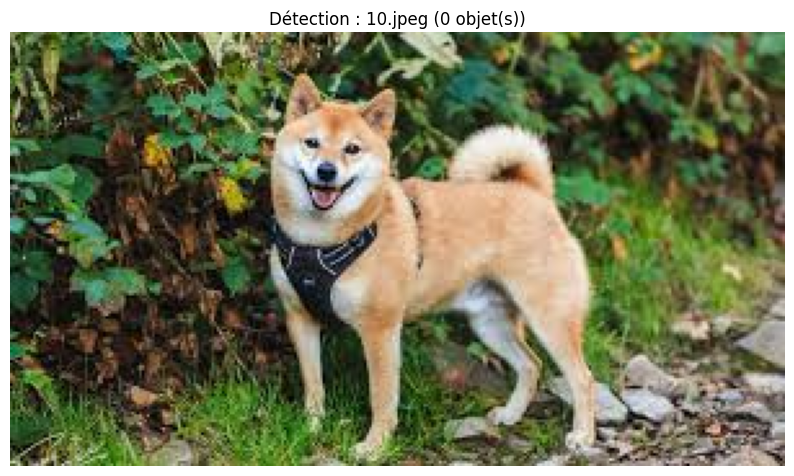


image 1/1 /Users/logame/Documents/cours ECM/yolo_training/yolo_split/images/val/6.jpeg: 384x640 (no detections), 30.2ms
Speed: 0.8ms preprocess, 30.2ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)


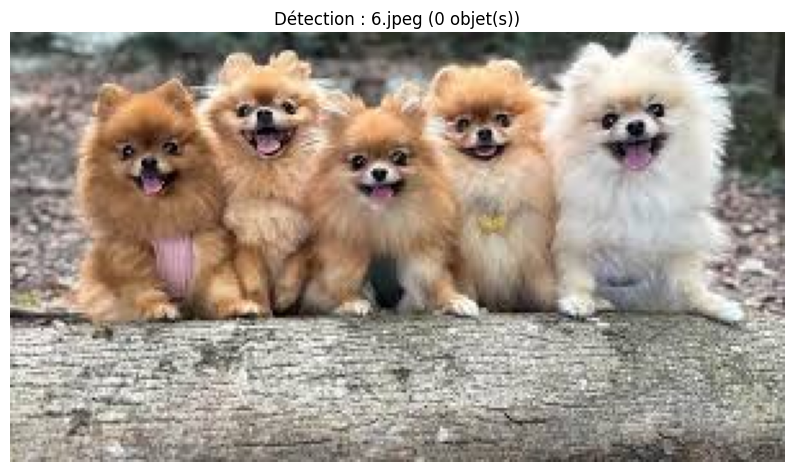

In [ ]:
# Chercher le meilleur modèle (best.pt) dans tous les emplacements possibles
best_candidates = []
for parent in [BASE_DIR / 'runs' / 'train', Path.home() / 'runs' / 'detect', Path.home() / 'runs' / 'detect' / 'runs' / 'train']:
    if parent.exists():
        for d in parent.glob('yolov8_custom*'):
            bp = d / 'weights' / 'best.pt'
            if bp.exists():
                best_candidates.append(bp)

if best_candidates:
    # Prendre le plus récent
    best_weights = max(best_candidates, key=lambda p: p.stat().st_mtime)
    trained_model = YOLO(str(best_weights))
    print(f"✅ Meilleur modèle chargé : {best_weights}")
else:
    print("⚠️  best.pt non trouvé, utilisation du modèle courant")
    trained_model = model

# Détection sur les images de validation avec seuil bas
val_images = list((OUTPUT_DIR / 'images' / 'val').glob('*'))
if val_images:
    for img_path in val_images:
        detect_results = trained_model(str(img_path), conf=0.1)  # Seuil bas pour voir les détections
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(detect_results[0].plot(), cv2.COLOR_BGR2RGB))
        nb = len(detect_results[0].boxes)
        plt.title(f"Détection : {img_path.name} ({nb} objet(s))")
        plt.axis('off')
        plt.show()
        # Afficher le détail
        for box in detect_results[0].boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            name = detect_results[0].names[cls_id]
            print(f"  → {name} ({conf*100:.1f}%)")
else:
    print("⚠️  Aucune image dans le dossier de validation.")

---

## 💡 Conseils pour améliorer vos résultats

- Vérifiez la qualité et la diversité de vos annotations.
- Essayez différents modèles (yolov8s.pt, yolov8m.pt, etc.).
- Ajustez le nombre d'époques, la taille des images, le batch size.
- Utilisez l'augmentation de données (data augmentation).
- Analysez les erreurs et améliorez vos labels si besoin.


Bravo ! Vous savez maintenant entraîner YOLOv8 sur vos propres données 🎉